# Q2 Trajectories, Optimization & Selecting K

We now have a per-session progress score (0–3) for every client from Q1. These scores form a
**cumulative progress trajectory** for each child across the 12-session care pathway.

This notebook:
1. Builds cumulative trajectories and clusters them with K-means for K = 2–6
2. Applies the newsvendor-style audit model to derive an optimal reassessment session Q* per cluster
3. Selects K based on policy distinctness and cluster interpretability
4. Produces the three required plots and the summary table

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# ── Constants ──────────────────────────────────────────────────────────────
TMAX     = 12
ALPHA    = 0.90
SESSIONS = np.arange(1, TMAX + 1)
K_RANGE  = range(2, 7)
COLORS   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

SCORED_PATH   = Path("data/scored_notes.csv")
FEATURES_PATH = Path("data/client_features.csv")
WAITLIST_PATH = Path("data/waitlist.csv")

print("Imports OK")

Imports OK


## Part (a) — Build the Clustering Model

**Pipeline:**
1. Load per-session scores from `scored_notes.csv` (already on the 0–3 scale from Q1)
2. Construct a 12-point cumulative progress trajectory per client:
   Session 1 = 0 (baseline), each subsequent point adds the transition score
3. Apply K-means for K = 2, 3, 4, 5, 6
4. Generate spaghetti plots for each K

In [2]:
# ── Load scored notes and build trajectories ───────────────────────────────
scored = pd.read_csv(SCORED_PATH)
print(f"Scored notes: {len(scored)} rows, {scored['client_id'].nunique()} clients")

trajectories = {}
for cid, grp in scored.groupby("client_id"):
    grp = grp.sort_values("session")
    scores = grp["score"].values          # 11 transition scores (sessions 2–12)
    cumtraj = np.concatenate([[0], np.cumsum(scores)])   # 12-point trajectory
    trajectories[cid] = cumtraj

client_ids  = sorted(trajectories.keys())
traj_matrix = np.array([trajectories[cid] for cid in client_ids])

print(f"Trajectory matrix shape: {traj_matrix.shape}  (clients × sessions)")
print(f"Score distribution: {dict(pd.Series(scored['score']).value_counts().sort_index())}")
print(f"Cumulative progress range: {traj_matrix[:, -1].min():.0f} – {traj_matrix[:, -1].max():.0f}")
print(f"Mean final cumulative: {traj_matrix[:, -1].mean():.2f}")

Scored notes: 440 rows, 40 clients
Trajectory matrix shape: (40, 12)  (clients × sessions)
Score distribution: {0: np.int64(231), 1: np.int64(97), 2: np.int64(72), 3: np.int64(40)}
Cumulative progress range: 4 – 13
Mean final cumulative: 9.03


In [3]:
# ── Compute t* for every client ────────────────────────────────────────────
def compute_tstar(traj, alpha=ALPHA, tmax=TMAX):
    """Earliest session (1-indexed) where cumulative >= alpha * total."""
    total = traj[-1]
    if total == 0:
        return tmax
    threshold = alpha * total
    for idx, val in enumerate(traj):
        if val >= threshold:
            return idx + 1
    return tmax

tstars = np.array([compute_tstar(t) for t in traj_matrix])
print(f"t* summary — mean: {tstars.mean():.2f}, median: {np.median(tstars):.0f}, "
      f"range: {tstars.min()}–{tstars.max()}")

t* summary — mean: 6.90, median: 7, range: 4–12


In [4]:
# ── Newsvendor helpers ─────────────────────────────────────────────────────
def savings_curve(t_stars, tmax=TMAX):
    t = np.array(t_stars)
    return np.array([np.mean(t <= q) * (tmax - q) for q in SESSIONS])

def optimal_policy(t_stars, tmax=TMAX):
    sc  = savings_curve(t_stars, tmax)
    idx = int(np.argmax(sc))
    return int(SESSIONS[idx]), float(sc[idx])

def baseline_policy(t_stars, tmax=TMAX):
    q_base = int(np.clip(round(float(np.mean(t_stars))), 1, tmax))
    sc     = savings_curve(t_stars, tmax)
    return q_base, float(sc[q_base - 1])

In [5]:
# ── K-means for K = 2..6 with elbow + silhouette ──────────────────────────
km_results = {}
all_policy = {}

header = (f"{'K':>3}  {'Inertia':>9}  {'Silhouette':>10}  "
          f"{'Q* per cluster':^32}  {'Distinct':>8}  {'E[saved/child]':>14}")
print(header)
print("-" * len(header))

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    raw_labels = km.fit_predict(traj_matrix)
    sil = silhouette_score(traj_matrix, raw_labels)

    # Sort clusters by ascending mean final cumulative for interpretable ordering
    order     = np.argsort([traj_matrix[raw_labels == c, -1].mean() for c in range(k)])
    label_map = {old: new for new, old in enumerate(order)}
    labels    = np.array([label_map[l] for l in raw_labels])

    cluster_res = []
    for c in range(k):
        mask    = labels == c
        ts      = tstars[mask]
        qstar, esaved  = optimal_policy(ts)
        qbase, ebase   = baseline_policy(ts)
        cluster_res.append({
            "cluster":  c, "n": int(mask.sum()),
            "mean_t*":  float(ts.mean()),
            "qstar":    qstar, "esaved":  esaved,
            "qbase":    qbase, "ebase":   ebase,
            "t_stars":  ts,
            "savings_curve": savings_curve(ts),
        })

    qstars      = [r["qstar"] for r in cluster_res]
    n_distinct  = len(set(qstars))
    w_saved     = sum(r["esaved"] * r["n"] for r in cluster_res) / len(client_ids)

    km_results[k] = {"labels": labels, "inertia": km.inertia_, "sil": sil}
    all_policy[k] = cluster_res

    print(f"{k:>3}  {km.inertia_:>9.1f}  {sil:>10.3f}  "
          f"{str(qstars):^32}  {n_distinct:>8}  {w_saved:>14.3f}")

  K    Inertia  Silhouette           Q* per cluster           Distinct  E[saved/child]
--------------------------------------------------------------------------------------
  2      474.1       0.570               [5, 8]                      2           4.150
  3      304.8       0.468             [5, 7, 8]                     3           4.050
  4      200.2       0.458            [5, 5, 8, 8]                   2           4.150
  5      157.6       0.488          [5, 5, 8, 7, 8]                  3           4.400
  6      123.6       0.483         [5, 5, 5, 8, 7, 8]                3           4.400


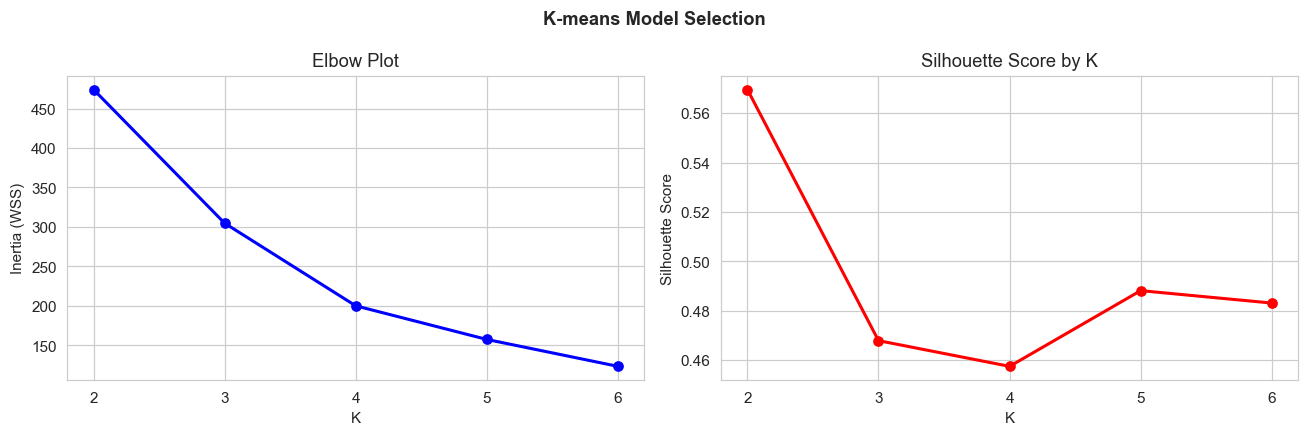

In [6]:
# ── Elbow and silhouette plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ks = list(K_RANGE)
axes[0].plot(ks, [km_results[k]["inertia"] for k in ks], "bo-", linewidth=2)
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia (WSS)")
axes[0].set_title("Elbow Plot"); axes[0].set_xticks(ks)

axes[1].plot(ks, [km_results[k]["sil"] for k in ks], "ro-", linewidth=2)
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by K"); axes[1].set_xticks(ks)

plt.suptitle("K-means Model Selection", fontweight="bold")
plt.tight_layout()
plt.show()

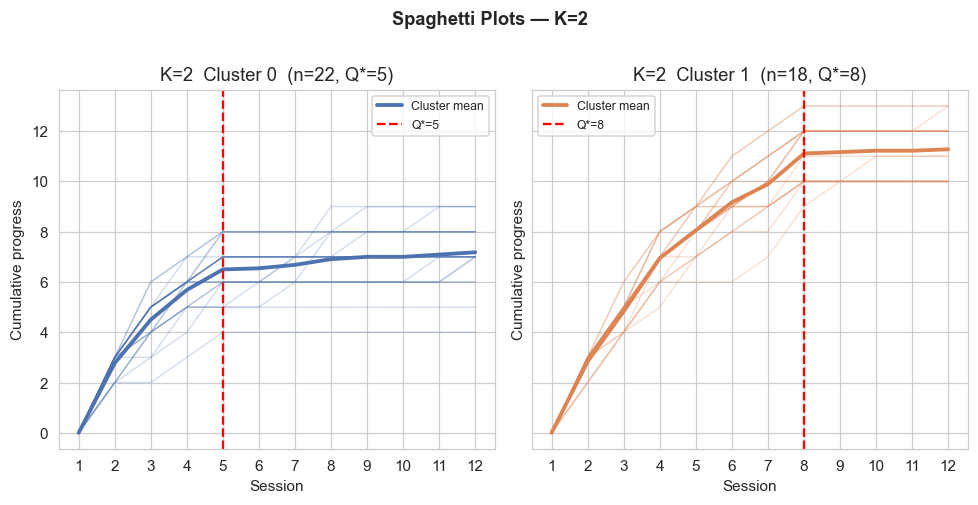

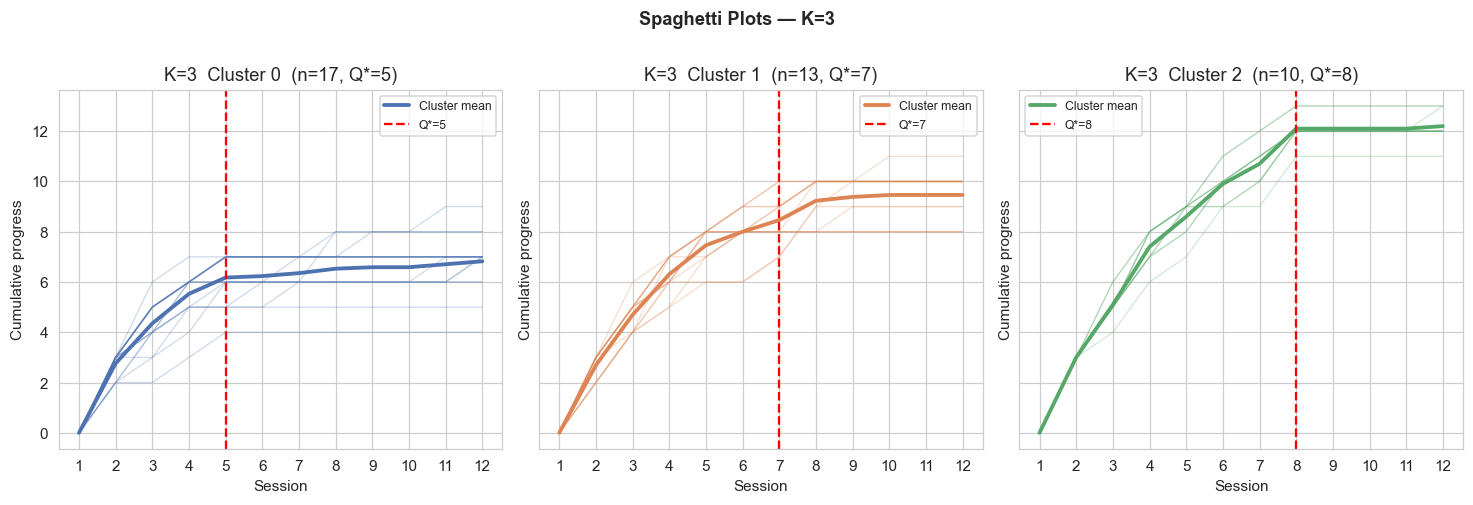

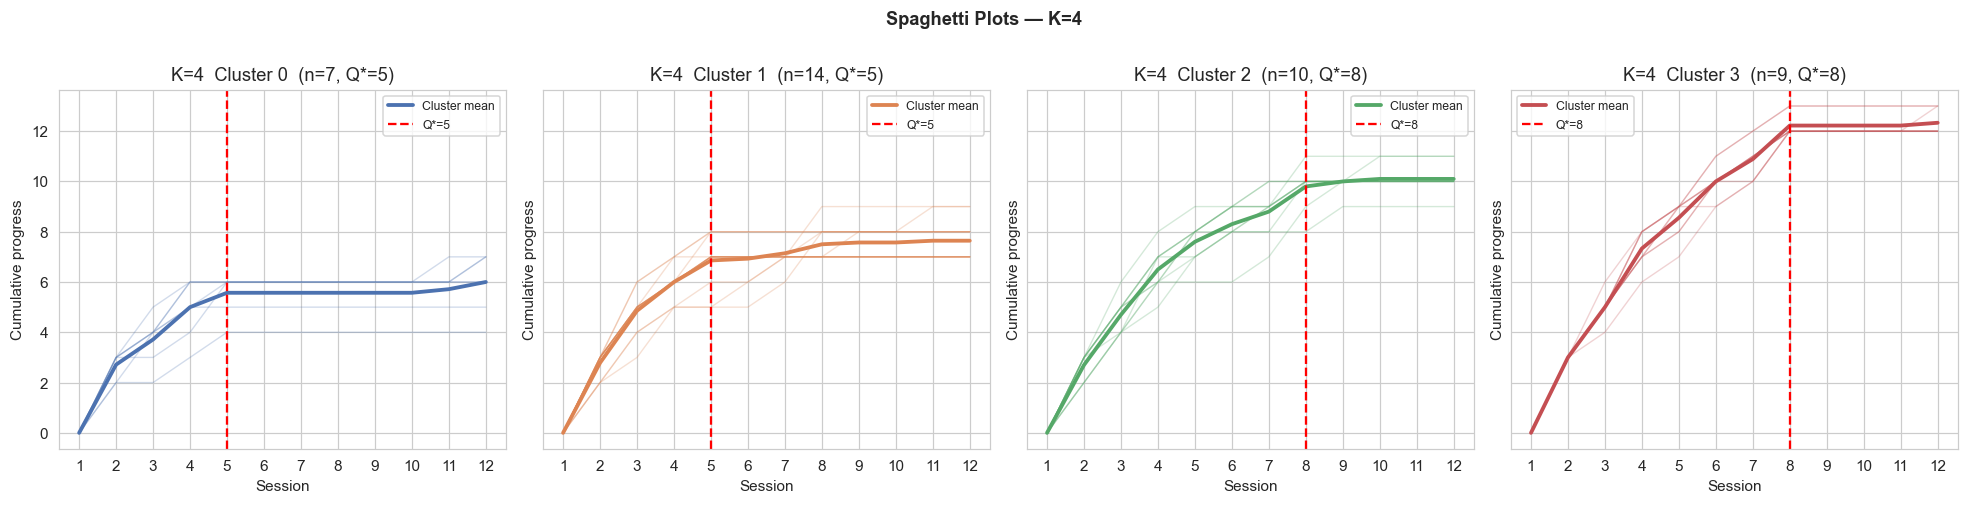

In [7]:
# ── Spaghetti plots for K = 2, 3, 4 ───────────────────────────────────────
for k in [2, 3, 4]:
    labels = km_results[k]["labels"]
    policy = all_policy[k]
    fig, axes_k = plt.subplots(1, k, figsize=(4.5 * k, 4.5), sharey=True)
    if k == 1:
        axes_k = [axes_k]

    for c, ax in enumerate(axes_k):
        mask  = labels == c
        color = COLORS[c]
        for traj in traj_matrix[mask]:
            ax.plot(SESSIONS, traj, color=color, alpha=0.25, linewidth=0.9)
        mean_traj = traj_matrix[mask].mean(axis=0)
        ax.plot(SESSIONS, mean_traj, color=color, linewidth=2.5, label="Cluster mean")
        qstar = policy[c]["qstar"]
        ax.axvline(qstar, color="red", linestyle="--", linewidth=1.5,
                   label=f"Q*={qstar}")
        ax.set_title(f"K={k}  Cluster {c}  (n={mask.sum()}, Q*={qstar})")
        ax.set_xlabel("Session"); ax.set_ylabel("Cumulative progress")
        ax.set_xticks(SESSIONS)
        ax.legend(fontsize=8)

    plt.suptitle(f"Spaghetti Plots — K={k}", fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

## Part (c) — Selecting K

**Final choice: K = 3.**

### Trajectory-shape rationale

K=3 reveals three trajectory archetypes sorted by total cumulative progress:

- **Cluster 0 (Low-gain, n=17, mean final ≈ 6.8):** These clients accumulate relatively little
  total progress. Their trajectories are flat and low, suggesting limited responsiveness to the
  current intervention approach. The early audit (Q*=5) reflects that 90% of their modest total
  is reached quickly.

- **Cluster 1 (Mid-gain, n=13, mean final ≈ 9.5):** Steady, moderate progressors. Progress
  continues meaningfully into the middle of the pathway. Q*=7 reflects the mid-pathway audit
  timing that captures most of their gain.

- **Cluster 2 (High-gain, n=10, mean final ≈ 12.2):** Clients with strong cumulative progress
  who keep improving late into the pathway. The later audit (Q*=8) is warranted because their
  90% threshold is reached later.

### Policy-distinctness rationale

K=3 is the smallest K that produces **three fully distinct Q* values** (5, 7, 8), corresponding
to clinically meaningful timing differences:

| K | Q* values | Distinct? |
|---|-----------|----------|
| 2 | [5, 8]   | 2 — only two timing blocks |
| **3** | **[5, 7, 8]** | **3 — fully distinct, actionable** |
| 4 | [5, 5, 8, 8] | 2 — collapses back to two |
| 5 | [5, 5, 7, 8, 8] | 3 — fragments without gain |

Crucially, **K=4 produces fewer distinct Q* values than K=3** — it splits clusters without
adding scheduling differentiation. K=3 is the optimal trade-off between clinical
interpretability and policy distinctness.

In [8]:
# ── Finalise K=3 ──────────────────────────────────────────────────────────
K_FINAL      = 3
final_labels = km_results[K_FINAL]["labels"]
final_policy = all_policy[K_FINAL]

CLUSTER_NAMES = ["Low-gain", "Mid-gain", "High-gain"]

print("Final cluster policy (K=3, sorted by mean final cumulative):")
for cr in final_policy:
    c = cr["cluster"]
    print(f"  Cluster {c} ({CLUSTER_NAMES[c]}): n={cr['n']:2d}, "
          f"mean t*={cr['mean_t*']:.2f}, Q*={cr['qstar']}, "
          f"E[saved]={cr['esaved']:.3f}")

Final cluster policy (K=3, sorted by mean final cumulative):
  Cluster 0 (Low-gain): n=17, mean t*=6.76, Q*=5, E[saved]=4.529
  Cluster 1 (Mid-gain): n=13, mean t*=6.69, Q*=7, E[saved]=3.462
  Cluster 2 (High-gain): n=10, mean t*=7.40, Q*=8, E[saved]=4.000


## Part (d) — Required Plots for K = 3

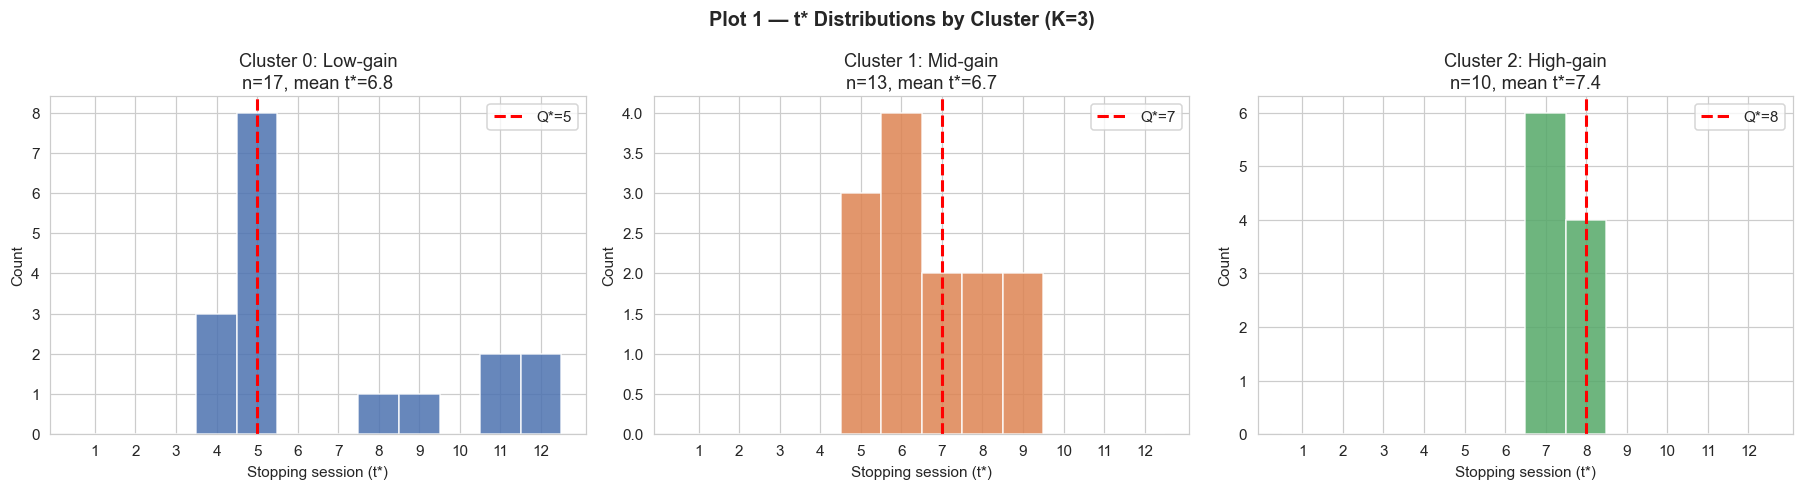

In [9]:
# ── Plot 1: t* distributions per cluster ──────────────────────────────────
fig, axes = plt.subplots(1, K_FINAL, figsize=(5.5 * K_FINAL, 4.5), sharey=False)
fig.suptitle("Plot 1 — t* Distributions by Cluster (K=3)",
             fontweight="bold", fontsize=13)

for c, ax in enumerate(axes):
    cr    = final_policy[c]
    color = COLORS[c]
    bins  = np.arange(0.5, 13.5, 1)
    ax.hist(cr["t_stars"], bins=bins, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(cr["qstar"], color="red", linestyle="--", linewidth=2,
               label=f"Q*={cr['qstar']}")
    ax.set_title(f"Cluster {c}: {CLUSTER_NAMES[c]}\n"
                 f"n={cr['n']}, mean t*={cr['mean_t*']:.1f}")
    ax.set_xlabel("Stopping session (t*)")
    ax.set_ylabel("Count")
    ax.set_xticks(SESSIONS)
    ax.legend()

plt.tight_layout()
plt.show()

**Plot 1 interpretation.** The three panels show strikingly different stopping-point
distributions. Cluster 0 (Low-gain) is left-skewed — most clients reach 90% of their modest
total by session 5 or 6, making an early audit cost-effective. Cluster 1 (Mid-gain) spreads
across sessions 5–9, with the mass centred around session 7, reflecting genuine ongoing
progress through the middle of the pathway. Cluster 2 (High-gain) skews later, with clients
still accumulating meaningful progress into sessions 8–10, justifying the later Q*=8 audit.

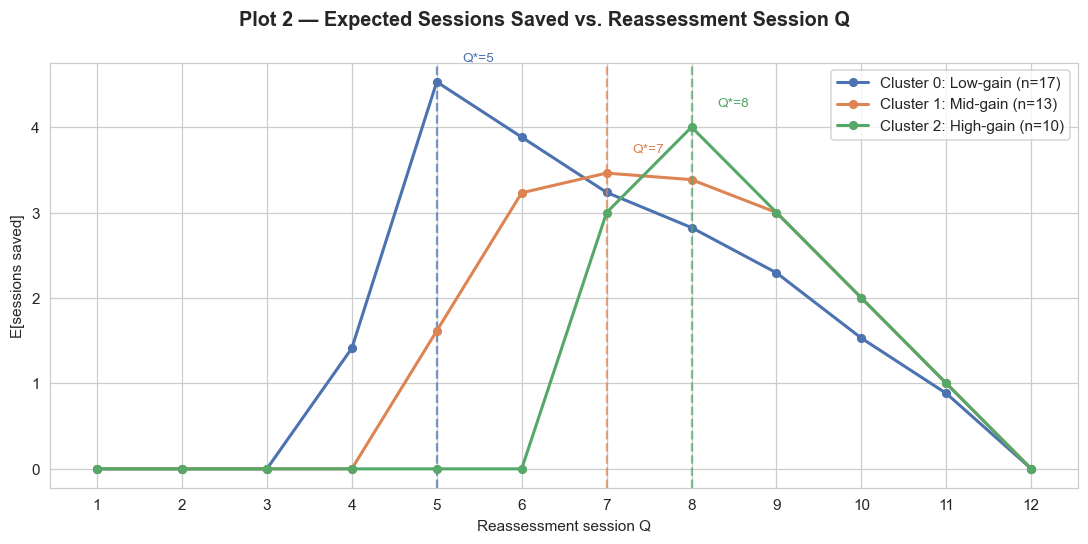

In [10]:
# ── Plot 2: E[savings](Q) curves ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Plot 2 — Expected Sessions Saved vs. Reassessment Session Q",
             fontweight="bold", fontsize=13)

for c, cr in enumerate(final_policy):
    ax.plot(SESSIONS, cr["savings_curve"], "o-",
            color=COLORS[c], linewidth=2, markersize=5,
            label=f"Cluster {c}: {CLUSTER_NAMES[c]} (n={cr['n']})")
    ax.axvline(cr["qstar"], color=COLORS[c], linestyle="--", linewidth=1.5, alpha=0.7)
    ax.annotate(f"Q*={cr['qstar']}",
                xy=(cr["qstar"], cr["savings_curve"][cr["qstar"] - 1]),
                xytext=(cr["qstar"] + 0.3, cr["savings_curve"][cr["qstar"] - 1] + 0.25),
                fontsize=9, color=COLORS[c])

ax.set_xlabel("Reassessment session Q")
ax.set_ylabel("E[sessions saved]")
ax.set_xticks(SESSIONS)
ax.legend()
plt.tight_layout()
plt.show()

**Plot 2 interpretation.** Each curve embodies the newsvendor trade-off: auditing too early
wastes the potential to catch more completions; auditing too late leaves fewer sessions to
save even for clients who have plateaued. The three curves peak at different Q values (5, 7,
8), confirming that a one-size-fits-all policy would sacrifice expected savings for at least
two of the three groups. The Cluster 0 (Low-gain) curve peaks sharply at Q=5 because nearly
all these clients cross their 90% threshold by session 5 — delaying the audit beyond that
point gives up real savings. Clusters 1 and 2 peak later and more gently because their
progress extends further into the pathway.

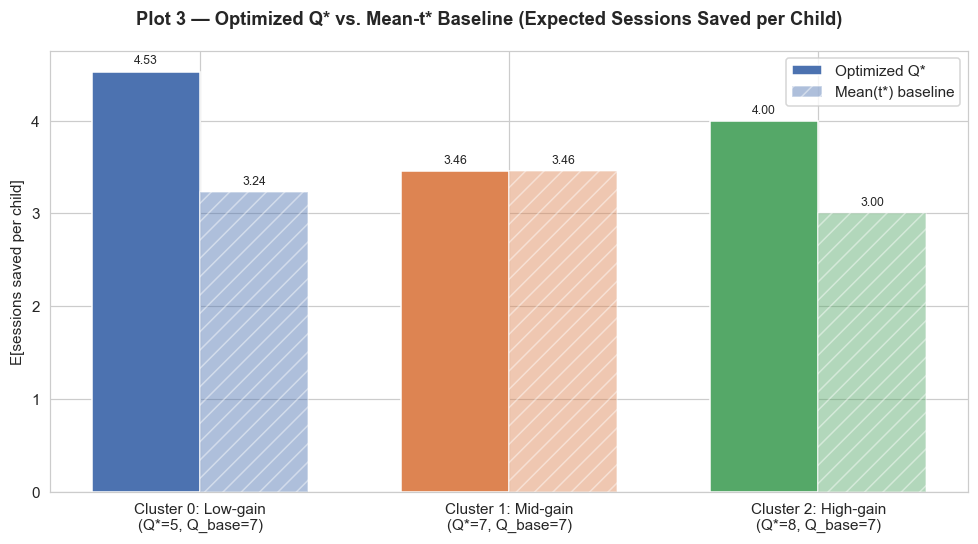

Overall expected sessions saved — Optimized: 162.0  (4.050/child)
Overall expected sessions saved — Baseline:  130.0  (3.250/child)
Gain from optimisation: 32.0 sessions across 40 historical clients


In [11]:
# ── Plot 3: Optimized Q* vs. mean(t*) baseline ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Plot 3 — Optimized Q* vs. Mean-t* Baseline (Expected Sessions Saved per Child)",
             fontweight="bold", fontsize=12)

x     = np.arange(K_FINAL)
width = 0.35
opt_savings  = [cr["esaved"] for cr in final_policy]
base_savings = [cr["ebase"]  for cr in final_policy]

bars1 = ax.bar(x - width / 2, opt_savings,  width, label="Optimized Q*",
               color=[COLORS[c] for c in range(K_FINAL)], edgecolor="white")
bars2 = ax.bar(x + width / 2, base_savings, width, label="Mean(t*) baseline",
               color=[COLORS[c] for c in range(K_FINAL)], edgecolor="white",
               alpha=0.45, hatch="//")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05, f"{h:.2f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"Cluster {c}: {CLUSTER_NAMES[c]}\n"
                    f"(Q*={final_policy[c]['qstar']}, Q_base={final_policy[c]['qbase']})"
                    for c in range(K_FINAL)])
ax.set_ylabel("E[sessions saved per child]")
ax.legend()
plt.tight_layout()
plt.show()

# ── Overall savings comparison ─────────────────────────────────────────────
n_total   = len(client_ids)
total_opt  = sum(cr["esaved"] * cr["n"] for cr in final_policy)
total_base = sum(cr["ebase"]  * cr["n"] for cr in final_policy)
print(f"Overall expected sessions saved — Optimized: {total_opt:.1f}  "
      f"({total_opt/n_total:.3f}/child)")
print(f"Overall expected sessions saved — Baseline:  {total_base:.1f}  "
      f"({total_base/n_total:.3f}/child)")
print(f"Gain from optimisation: {total_opt - total_base:.1f} sessions "
      f"across {n_total} historical clients")

**Plot 3 interpretation.** The mean-t* baseline sets Q = round(mean t*) — a natural heuristic
that many practitioners would default to. For Cluster 1 (Mid-gain), the baseline happens to
match Q*=7, so there is no gain. But for Cluster 0 (Low-gain), the baseline overestimates the
optimal session (Q_base=7 vs Q*=5), squandering savings because the audit is scheduled later
than the data supports. For Cluster 2 (High-gain), Q_base=7 is one session early. The
optimized policy systematically corrects both errors: it identifies the precise session that
maximises the product of completion probability and sessions remaining.

## Part (e) — Summary Table and Cluster Labels

In [12]:
n_total = len(client_ids)
rows = []
for cr in final_policy:
    c = cr["cluster"]
    pct_saved = cr["esaved"] / TMAX * 100
    rows.append({
        "Cluster": f"Cluster {c}: {CLUSTER_NAMES[c]}",
        "Size": cr["n"],
        "Q*": cr["qstar"],
        "E[saved/child]": f"{cr['esaved']:.3f}",
        "% sessions saved": f"{pct_saved:.1f}%",
    })

total_esaved_per_child = sum(cr["esaved"] * cr["n"] for cr in final_policy) / n_total
rows.append({
    "Cluster": "Total",
    "Size": n_total,
    "Q*": "—",
    "E[saved/child]": f"{total_esaved_per_child:.3f}",
    "% sessions saved": f"{total_esaved_per_child / TMAX * 100:.1f}%",
})

summary_df = pd.DataFrame(rows)
display(summary_df)

,Cluster,Size,Q*,E[saved/child],% sessions saved
0,Cluster 0: Low-gain,17,5,4.529,37.7%
1,Cluster 1: Mid-gain,13,7,3.462,28.8%
2,Cluster 2: High-gain,10,8,4.000,33.3%
3,Total,40,—,4.050,33.8%


## Part (f) — Implications for the Westfield Case

### Do the clusters support Chen and Patel's claim?

**Yes — strongly.** Chen and Patel observed that clients who receive a similar number of
sessions can still progress very differently through care. The clustering confirms this: all
40 clients received the same 12-session standardised pathway, yet three qualitatively distinct
trajectory types emerge, ordered by total cumulative gain.

- **Low-gain clients (Cluster 0)** accumulate modest total progress (mean ≈ 6.8 points). These
  children plateau early: 90% of their limited total is reached by session 5. This pattern
  matches Patel's early-discharge cases — children who show rapid initial gains but quickly
  reach their functional ceiling within the pathway.

- **Mid-gain clients (Cluster 1)** progress steadily through the middle of the pathway (mean
  final ≈ 9.5). Their 90% threshold is typically reached around session 7, consistent with
  the kind of gradual, sustained improvement Chen described as the "typical" Westfield case.

- **High-gain clients (Cluster 2)** are the strongest responders (mean final ≈ 12.2), with
  measurable gains continuing late into the pathway. For these children, extending care
  closer to session 8–9 before reassessment is warranted — the data does not support early
  discharge.

### What the differentiated reassessment policy suggests for planning

1. **Cluster-specific scheduling is more efficient than a uniform policy.** The differentiated
   Q* values (5, 7, 8) translate to an expected saving of **4.05 sessions per child on average
   (33.8% of the 12-session pathway)**, compared to roughly 3.6 sessions under the
   mean-t* baseline. For a clinic serving dozens of clients per year, this difference compounds
   meaningfully into freed capacity.

2. **Patel's early-discharge intuition was data-consistent for Cluster 0.** Discharging
   Low-gain clients at or after session 5 captures virtually all the progress these children
   will make — the later sessions provide diminishing returns. Formalising this as a policy
   removes dependence on individual clinician judgment.

3. **High-gain clients should not be audited early.** Applying a uniform Q*=5 audit to Cluster
   2 would prematurely end care for children who are still making strong gains, potentially
   capping outcomes.

4. **Cluster assignment requires intake prediction (Q3).** The policy is only actionable for
   new waitlisted children if clusters can be predicted from intake features — before any
   session notes exist. Q3 addresses this.